# Visualisation and Abalation Studies

The contains models and its training in this notebook. If you don't want to spent the time, run the entirely at once.

## Visualition of weights and mainly attention block

In [1]:
# importing libraries
import torch
from torch import nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"

In [3]:
from dataset.dataset import createDatasets
from torch.utils.data import DataLoader

dataset = pd.read_csv("./ranking_dataset.csv") 
(train_dataset, test_dataset, valid_dataset),(train_size, test_size, valid_size) = createDatasets(dataset,.1,.1)

train_data = DataLoader(train_dataset,batch_size=64)
valid_data = DataLoader(valid_dataset,batch_size=4096)
test_data = DataLoader(test_dataset,batch_size=4096)

In [118]:
import torch
from torch import mean, nn
import numpy as np


class AddAndNormalise(nn.Module):
    def __init__(self):
        super().__init__()
        self.a = nn.Parameter(torch.ones(1))
        self.b = nn.Parameter(torch.zeros(1))


    def forward(self,x,y):
        ep = 1e-5
        h = torch.concat([x,y],dim = -1)
        return self.a*(h - torch.mean(h,dim = -1,keepdim=True))/(torch.std(h,dim=-1,keepdim=True)+ep) + self.b


class MultiHeadAttention(nn.Module):
    def __init__(self,nheads,input_dim,attention_layers,device):
        super().__init__()
        self.device = device
        self.W_Q = nn.Parameter(torch.randn((input_dim,attention_layers*nheads))/input_dim**.5)
        self.W_K = nn.Parameter(torch.randn((input_dim,attention_layers*nheads))/input_dim**.5)
        self.W_V = nn.Parameter(torch.randn((input_dim,attention_layers*nheads))/input_dim**.5)
        self.W_O = nn.Parameter(torch.randn((attention_layers*nheads,attention_layers*nheads))/(attention_layers)**.5)

        self.sf = nn.Softmax(dim=-1)
        self.attention_layers = attention_layers
        self.nheads = nheads

    def forward(self,x):
        batchsize, input_len = x.shape[0],x.shape[1]
        Q = x@self.W_Q
        K = x@self.W_K
        V = x@self.W_V

        """
        previous attempt
        Qs = torch.chunk(Q,self.nheads,dim = -1)
        Ks = torch.chunk(K,self.nheads,dim = -1)
        Vs = torch.chunk(V,self.nheads,dim = -1)
        c = torch.concat([self.scaledDotProduct(Qs[i],Ks[i],Vs[i]) for i in range(self.nheads)],dim=-1)
        return c@self.W_O
        """
        
        Qs = Q.reshape(batchsize,input_len,self.nheads,self.attention_layers).transpose(1,2)
        Ks = K.reshape(batchsize,input_len,self.nheads,self.attention_layers).transpose(1,2)
        Vs = V.reshape(batchsize,input_len,self.nheads,self.attention_layers).transpose(1,2)

        out = self.scaledDotProduct(Qs,Ks,Vs).transpose(1,2).reshape(batchsize,input_len,-1)
        return out@self.W_O
        

    def scaledDotProduct(self,Q,K,V):
        return self.sf(1/torch.sqrt(torch.Tensor([Q.shape[-1]]).to(self.device))*(Q@(K.transpose(-1,-2))))@V


class EncoderOnlyTransformerPredictor2(torch.nn.Module):
    def __init__(self,device):
        super().__init__()
        self.device = device
        self.att = MultiHeadAttention(4,2,16,device)
        self.norm = AddAndNormalise()
        self.W_1 = nn.Parameter(torch.randn((4*16+2,64))/66**0.5)
        self.b_1 = nn.Parameter(torch.randn(64)*0.1)
        self.W_2 = nn.Parameter(torch.randn((64,10))/8)
        self.b_2 = nn.Parameter(torch.randn(10)*0.1)
        self.r = nn.ReLU()
        self.ff = lambda x : self.r(x@self.W_1+self.b_1)@self.W_2 + self.b_2

    def forward(self,x):
        x2 = self.position_embedded(x)
        x3 = self.att(x2)
        x4 = self.norm(x2,x3)
        
        x5 = self.ff(x4)
        return x5

    def position_embedded(self,x):
        x = x.reshape(-1,x.shape[1],1)
        P = torch.zeros_like(x)
        for i in range(x.shape[1]):
            P[:,i,0] = (1.5)**(-i)
            #P[:,i,0] = np.sin(i)
        return torch.concat([x,P], dim = -1)


In [119]:
model = EncoderOnlyTransformerPredictor2(device)
model.to(device)
model.load_state_dict(torch.load("./EncoderOnlyTransformerPredictor2/model_parameter.trhmodel"))

<All keys matched successfully>

In [120]:
model.eval()

EncoderOnlyTransformerPredictor2(
  (att): MultiHeadAttention(
    (sf): Softmax(dim=-1)
  )
  (norm): AddAndNormalise()
  (r): ReLU()
)

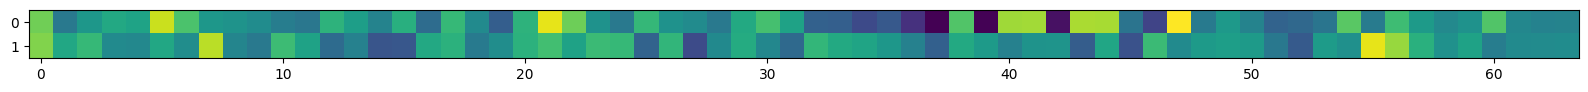

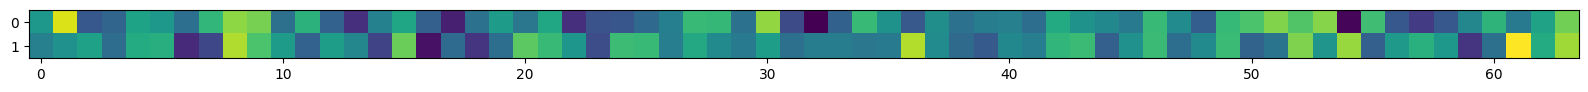

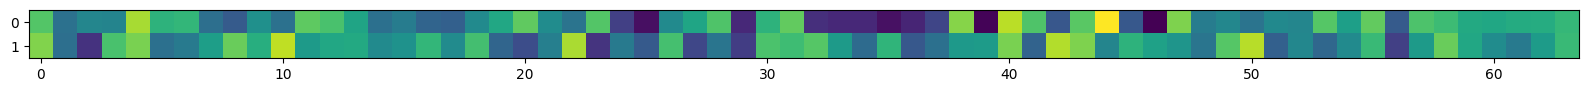

In [121]:
model.eval()
plt.figure(figsize=(20, 20))
plt.imshow(model.att.W_Q.cpu().detach().numpy())
plt.show()
plt.figure(figsize=(20, 20))
plt.imshow(model.att.W_V.cpu().detach().numpy())
plt.show()
plt.figure(figsize=(20, 20))
plt.imshow(model.att.W_K.cpu().detach().numpy())
plt.show()

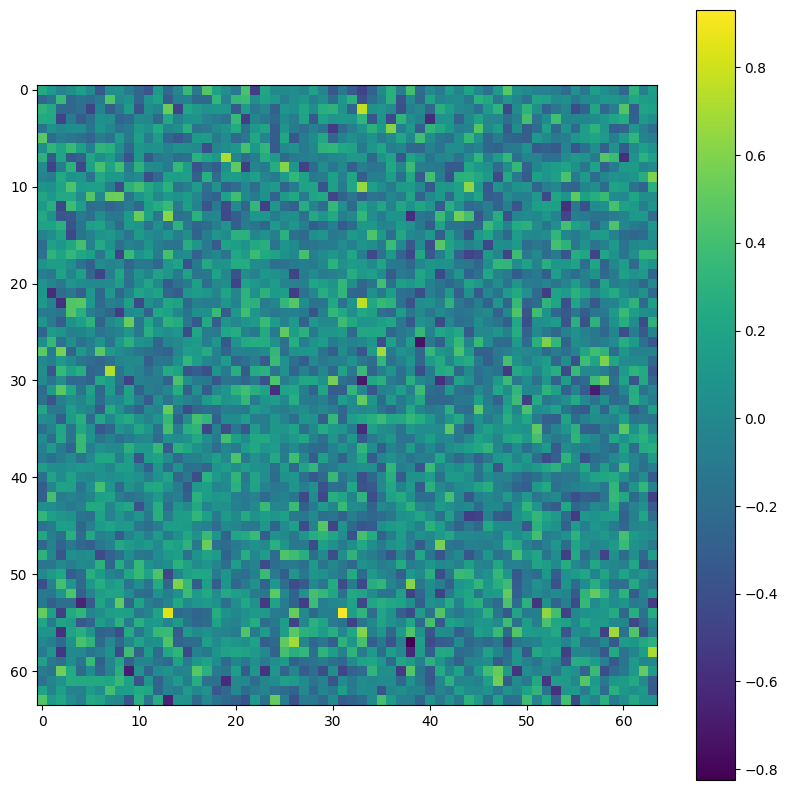

In [122]:
plt.figure(figsize=(10, 10))
plt.imshow(model.att.W_O.cpu().detach().numpy())
plt.colorbar()

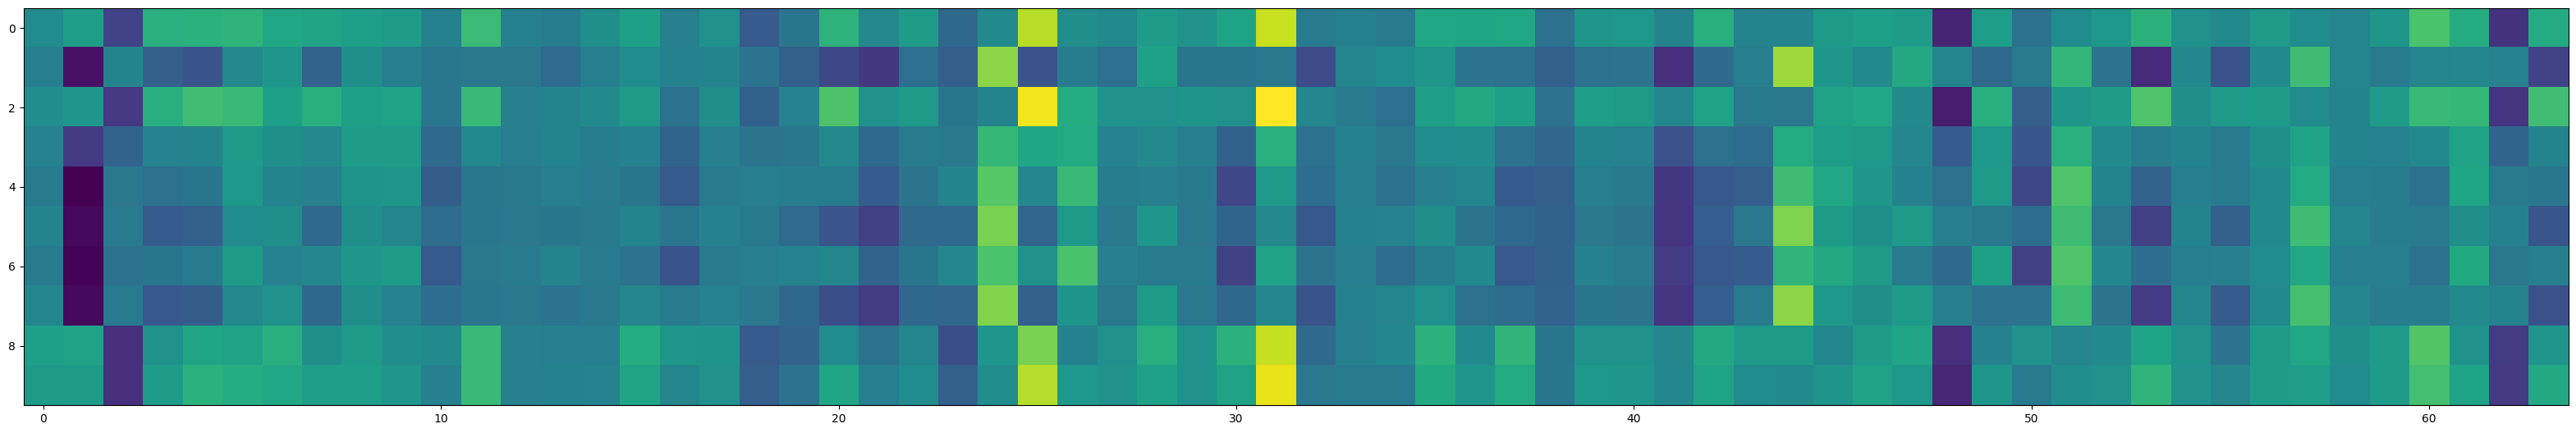

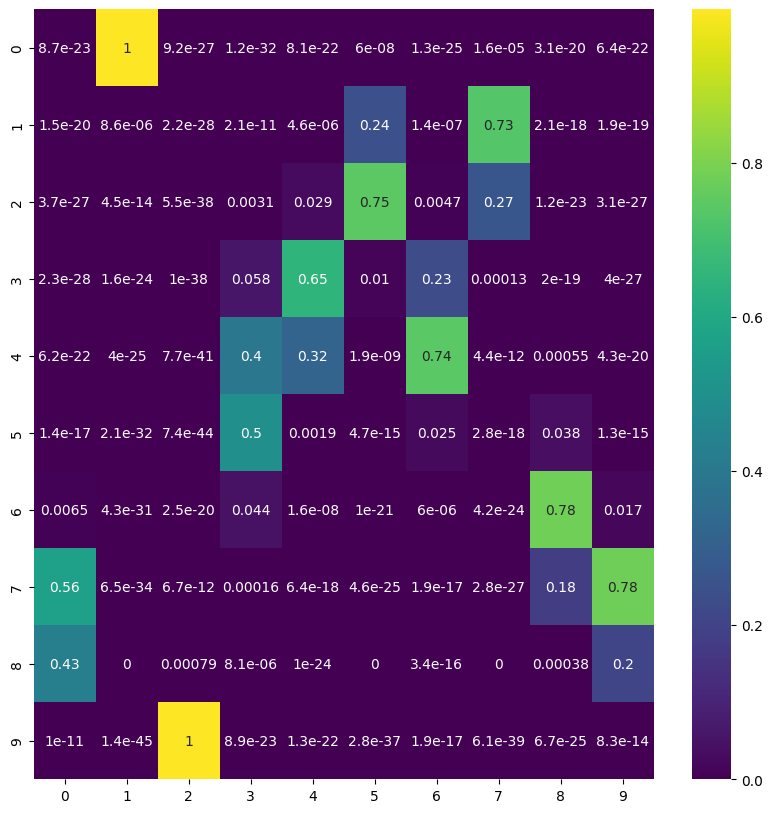

[8 0 9 5 3 2 4 1 6 7]
tensor([[7, 0, 9, 5, 3, 2, 4, 1, 6, 7]])


In [123]:
x,y = test_dataset[0]
x = x.reshape(1,10).to(device)
x2 = model.position_embedded(x)
x3 = model.att(x2)
plt.figure(figsize=(40, 20))
plt.imshow(x3.cpu().detach().numpy()[0])
plt.show()
#print(x3.shape)
x4 = model.norm(x2,x3)
x5 = model.ff(x4)
plt.figure(figsize=(10, 10))
sns.heatmap(torch.softmax(x5,dim=-1).mT.cpu().detach().numpy()[0],annot=True,cmap="viridis")
plt.show()
print(y)
print(torch.argmax(torch.softmax(x5,dim=-1).cpu(),dim=-1))

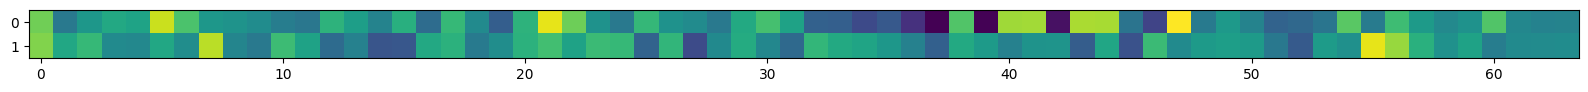

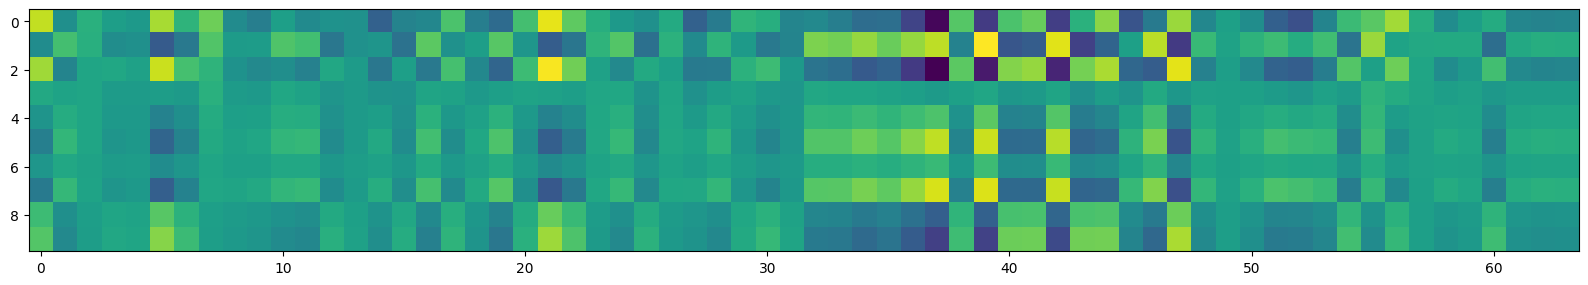

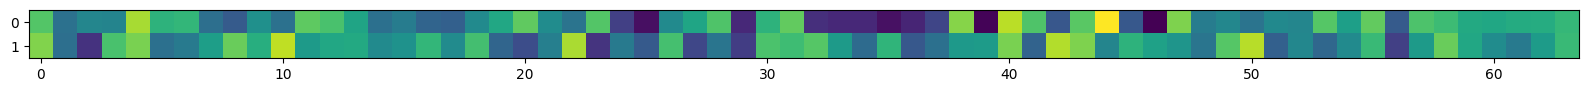

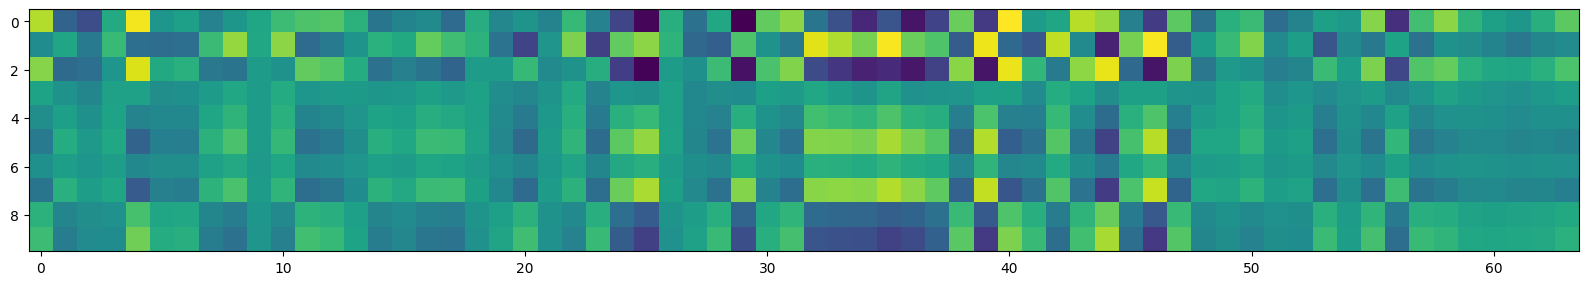

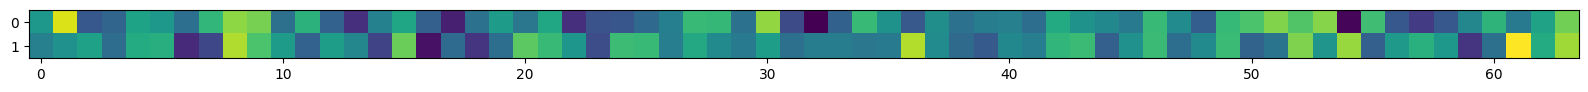

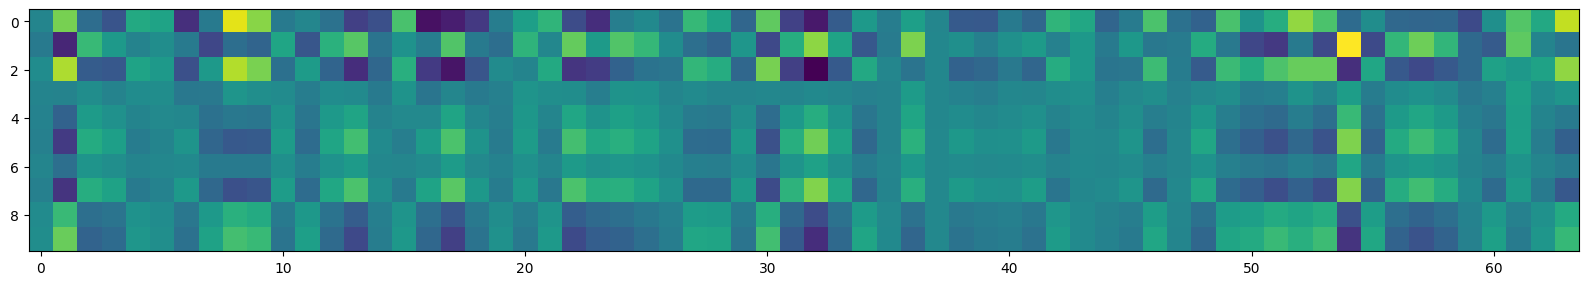

In [124]:
Q = x2@model.att.W_Q
K = x2@model.att.W_K
V = x2@model.att.W_V
plt.figure(figsize=(20, 20))
plt.imshow(model.att.W_Q.cpu().detach().numpy())
plt.show()
plt.figure(figsize=(20, 20))
plt.imshow(Q.cpu().detach().numpy()[0])
plt.show()
plt.figure(figsize=(20, 20))
plt.imshow(model.att.W_K.cpu().detach().numpy())
plt.show()
plt.figure(figsize=(20, 20))
plt.imshow(K.cpu().detach().numpy()[0])
plt.show()
plt.figure(figsize=(20, 20))
plt.imshow(model.att.W_V.cpu().detach().numpy())
plt.show()
plt.figure(figsize=(20, 20))
plt.imshow(V.cpu().detach().numpy()[0])
plt.show()

torch.Size([1, 10, 16])


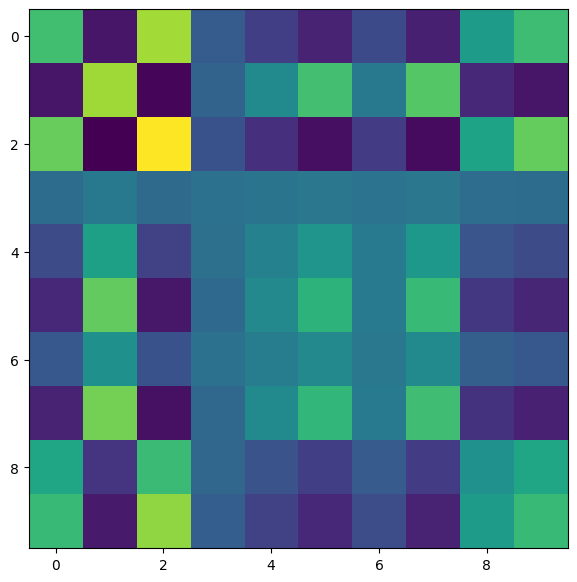

[8 0 9 5 3 2 4 1 6 7]
tensor([[7, 0, 9, 5, 3, 2, 4, 1, 6, 7]])


In [125]:
# Attention score of a head

Q = (x2@model.att.W_Q)[:,:,:model.att.attention_layers]
K = (x2@model.att.W_K)[:,:,:model.att.attention_layers]
V = (x2@model.att.W_V)[:,:,:model.att.attention_layers]

att_sc = model.att.sf(Q@(K.mT)/(model.att.attention_layers**0.5))
print(Q.shape)
plt.figure(figsize=(7, 7))
plt.imshow(att_sc.cpu().detach().numpy()[0])
plt.show()

print(y)
print(torch.argmax(torch.softmax(x5,dim=-1).cpu(),dim=-1))

torch.Size([1, 10, 16])


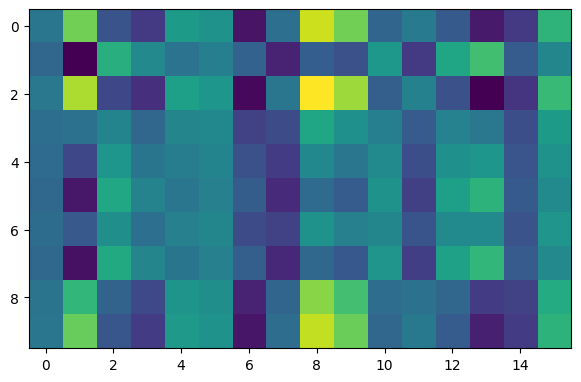

[8 0 9 5 3 2 4 1 6 7]
tensor([[7, 0, 9, 5, 3, 2, 4, 1, 6, 7]])


In [126]:
# after applying Attention score 
W = att_sc@V
print(Q.shape)
plt.figure(figsize=(7, 7))
plt.imshow(W.cpu().detach().numpy()[0])
plt.show()

print(y)
print(torch.argmax(torch.softmax(x5,dim=-1).cpu(),dim=-1))

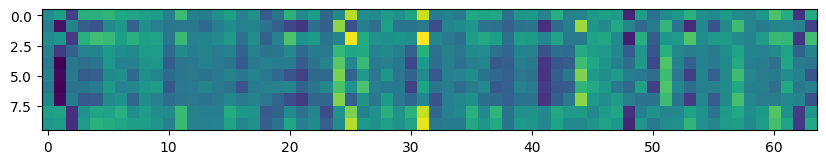

In [127]:
plt.figure(figsize=(10,10))
plt.imshow(x3.cpu().detach().numpy()[0])
plt.show()

tensor([-1.4863, -1.1560, -0.8257, -0.4954, -0.1651,  0.1651,  0.4954,  0.8257,
         1.1560,  1.4863], device='cuda:0')
tensor([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]])


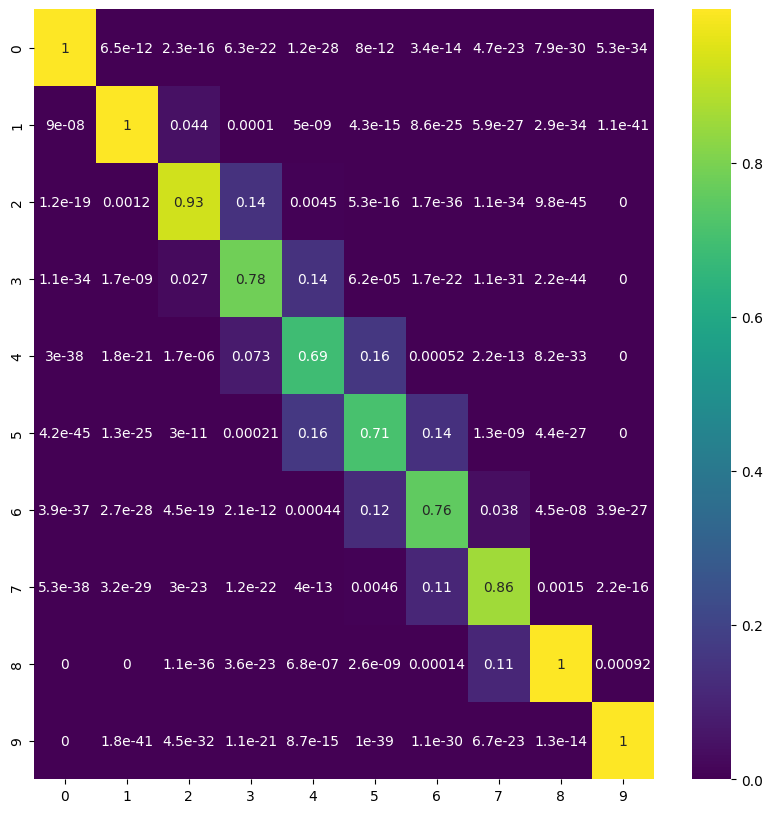

In [128]:
# Testing some examples

test = torch.Tensor([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).to(device)
test = (test - test.mean())/test.std()
x5 = model(test.reshape(1,10)).reshape(-1,10,10)
plt.figure(figsize=(10, 10))
print(test)
print(torch.argmax(torch.softmax(x5,dim=-1).cpu(),dim=-1))
sns.heatmap(torch.softmax(x5,dim=-1).mT.cpu().detach().numpy()[0],annot=True,cmap="viridis")
plt.show()

tensor([ 1.4863,  1.1560,  0.8257,  0.4954,  0.1651, -0.1651, -0.4954, -0.8257,
        -1.1560, -1.4863], device='cuda:0')
tensor([[9, 8, 7, 6, 5, 4, 3, 2, 1, 0]])


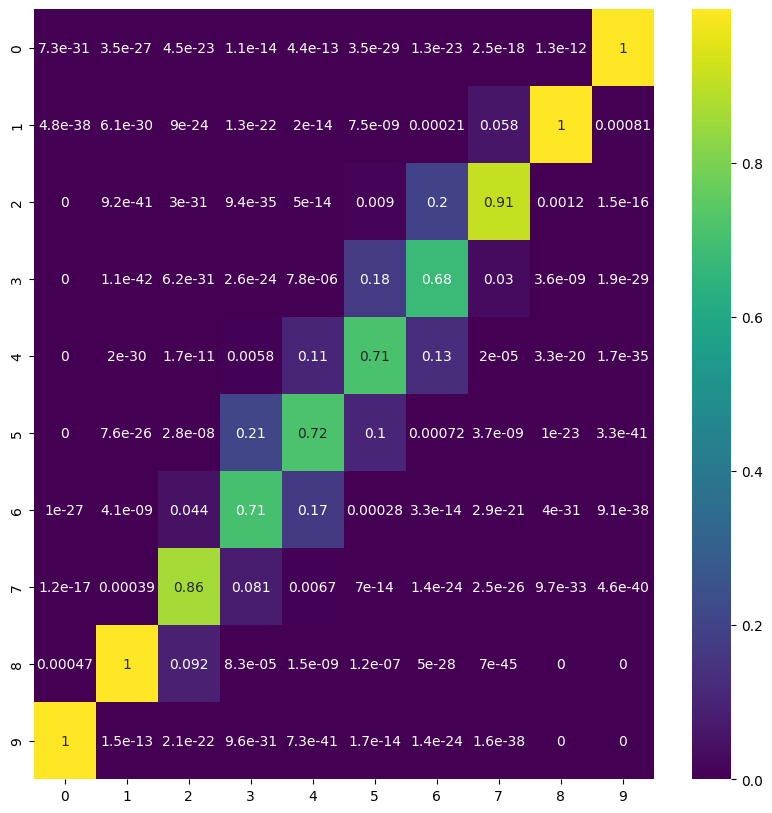

In [129]:
# Testing some examples

test = torch.Tensor([1000,900,800,700,600,500,400,300,200,100]).to(device)
test = (test - test.mean())/test.std()
x5 = model(test.reshape(1,10)).reshape(-1,10,10)
plt.figure(figsize=(10, 10))
print(test)
print(torch.argmax(torch.softmax(x5,dim=-1).cpu(),dim=-1))
sns.heatmap(torch.softmax(x5,dim=-1).mT.cpu().detach().numpy()[0],annot=True,cmap="viridis")
plt.show()

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0')
tensor([[5, 5, 5, 5, 5, 5, 5, 5, 5, 5]])


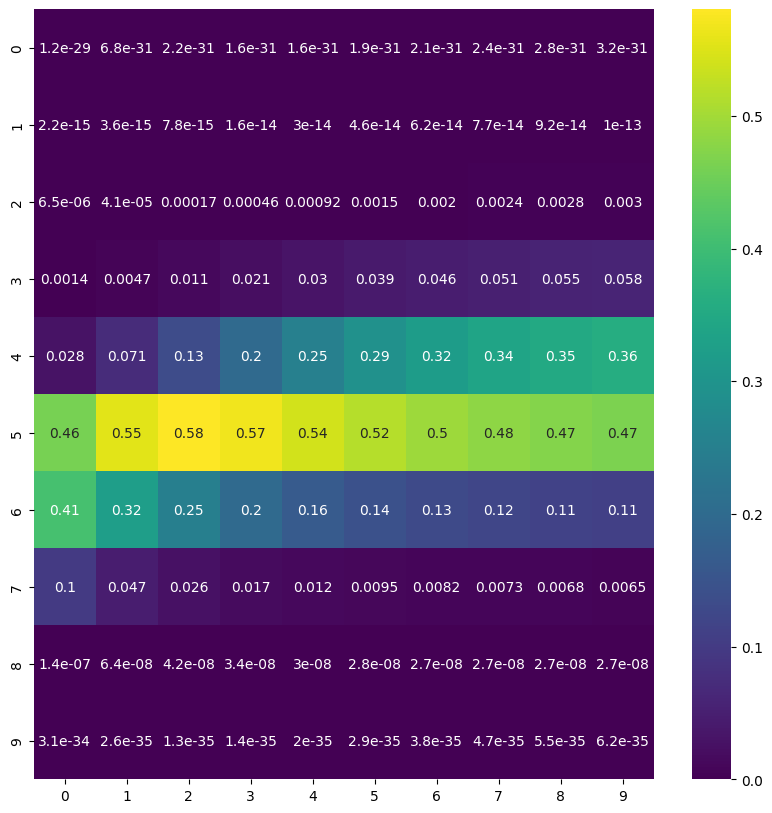

In [130]:
# Testing some examples

test = torch.Tensor([0,0,0,0,0,0,0,0,0,0]).to(device)
#test = (test - test.mean())/test.std()
x5 = model(test.reshape(1,10)).reshape(-1,10,10)
plt.figure(figsize=(10, 10))
print(test)
print(torch.argmax(torch.softmax(x5,dim=-1).cpu(),dim=-1))
sns.heatmap(torch.softmax(x5,dim=-1).mT.cpu().detach().numpy()[0],annot=True,cmap="viridis")
plt.show()

tensor([-1.2649, -0.6325,  0.0000,  0.6325,  1.2649], device='cuda:0')
tensor([[5, 5, 5, 4, 4]])


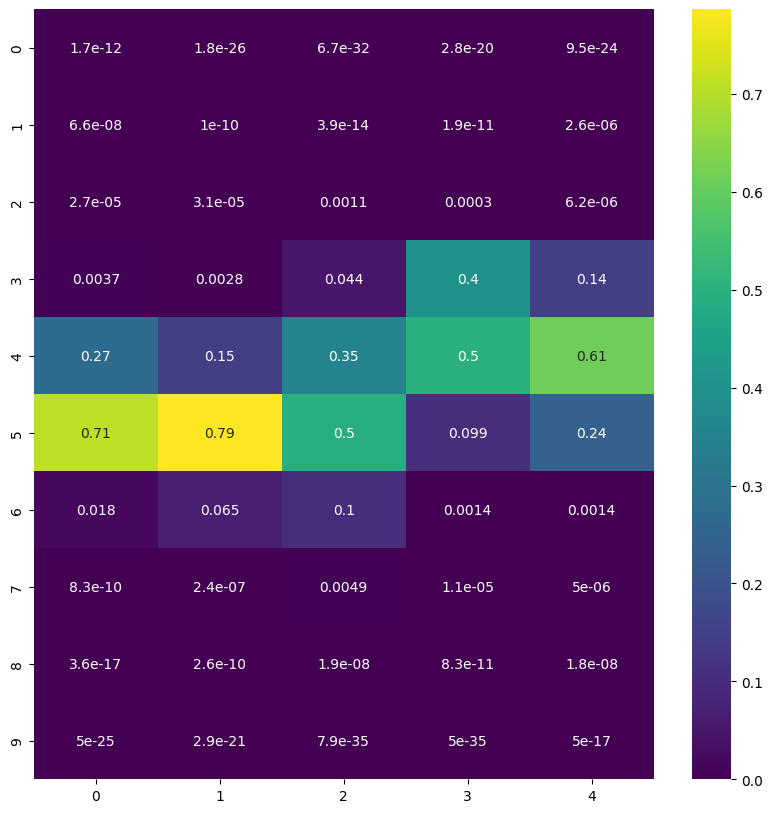

In [131]:
# Testing some examples

test = torch.Tensor([1,2,3,4,5]).to(device)
test = (test - test.mean())/test.std()
x5 = model(test.reshape(1,-1)).reshape(1,-1,10)
plt.figure(figsize=(10, 10))
print(test)
print(torch.argmax(torch.softmax(x5,dim=-1).cpu(),dim=-1))
sns.heatmap(torch.softmax(x5,dim=-1).mT.cpu().detach().numpy()[0],annot=True,cmap="viridis")
plt.show()

well the model doesn't generalises to different length sequences

## Abalation Studies

In [132]:
import torch
import numpy as np
from torch.utils.data import Dataset,random_split


def createDatasets(DatasetClass,data,valid_ratio = .1, test_ratio = .1):
    dataset = DatasetClass(data)
    test_size = int(test_ratio*len(dataset))
    valid_size = int(valid_ratio*len(dataset))
    training_size = len(dataset) - test_size - valid_size
    (train_dataset, test_dataset, valid_dataset) = random_split(dataset, [training_size,test_size,valid_size])
    return (train_dataset, test_dataset, valid_dataset), (training_size, test_size, valid_size) 

In [133]:
class RawNumArrayDataset(Dataset):
    """
    Dataset for model
    
    One-hot encoding is done for the ranks and the input as in the values are normalised
    """
    def __init__(self,data):
        self.data = np.array(data,dtype = "int")
        self.x = torch.Tensor(self.data[:,:10])
        self.y = self.data[:,10:]

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self,i):
        return (self.x[i],self.y[i])

In [134]:
ep = 1e-5

class MaxminNumArrayDataset(Dataset):
    """
    Dataset for model
    
    One-hot encoding is done for the ranks and the input as in the values are normalised
    """
    def __init__(self,data):
        self.data = np.array(data,dtype = "int")
        self.x = torch.Tensor(self.data[:,:10])
        self.y = self.data[:,10:]

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self,i):
        self.x[i] = self.x[i] - torch.min(self.x[i],dim=-1).values
        self.x[i] /= torch.max(self.x[i],dim=-1).values + ep
        return (self.x[i],self.y[i])

In [135]:
class ZScoreNumArrayDataset(Dataset):
    """
    Dataset for model
    
    One-hot encoding is done for the ranks and the input as in the values are normalised
    """
    def __init__(self,data):
        self.data = np.array(data,dtype = "int")
        self.x = torch.Tensor(self.data[:,:10])
        self.y = self.data[:,10:]

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self,i):
        self.x[i] -= self.x[i].mean()
        self.x[i] /= self.x[i].std()
        return (self.x[i],self.y[i])

In [136]:
from torch.utils.data import DataLoader


In [137]:
def getOutput(Datasetclass):
    
    dataset = pd.read_csv("./ranking_dataset.csv") 
    (train_dataset, test_dataset, valid_dataset),(train_size, test_size, valid_size) = createDatasets(Datasetclass,dataset,.1,.1)
    
    train_data = DataLoader(train_dataset,batch_size=64)
    valid_data = DataLoader(valid_dataset,batch_size=4096)
    test_data = DataLoader(test_dataset,batch_size=4096)
    
    x,y = test_dataset[0]
    x = x.reshape(1,10).to(device)
    x2 = model.position_embedded(x)
    x3 = model.att(x2)
    #print(x3.shape)
    x4 = model.norm(x2,x3)
    x5 = model.ff(x4)
    plt.figure(figsize=(10, 10))
    sns.heatmap(torch.softmax(x5,dim=-1).mT.cpu().detach().numpy()[0],annot=True,cmap="viridis")
    plt.show()
    print(x,y)
    print(torch.argmax(torch.softmax(x5,dim=-1).cpu(),dim=-1))

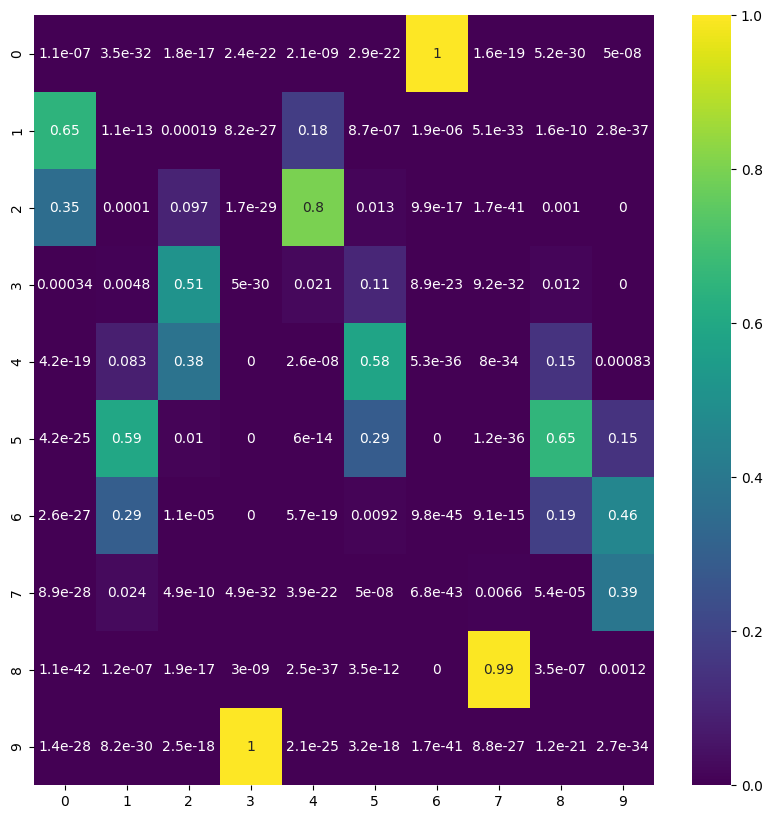

tensor([[-0.7966, -0.0215, -0.4682,  2.2497, -0.7104, -0.3714, -1.0603,  1.1033,
         -0.1830,  0.2583]], device='cuda:0') [1 6 3 9 2 4 0 8 5 7]
tensor([[1, 5, 3, 9, 2, 4, 0, 8, 5, 6]])


In [138]:
getOutput(ZScoreNumArrayDataset)

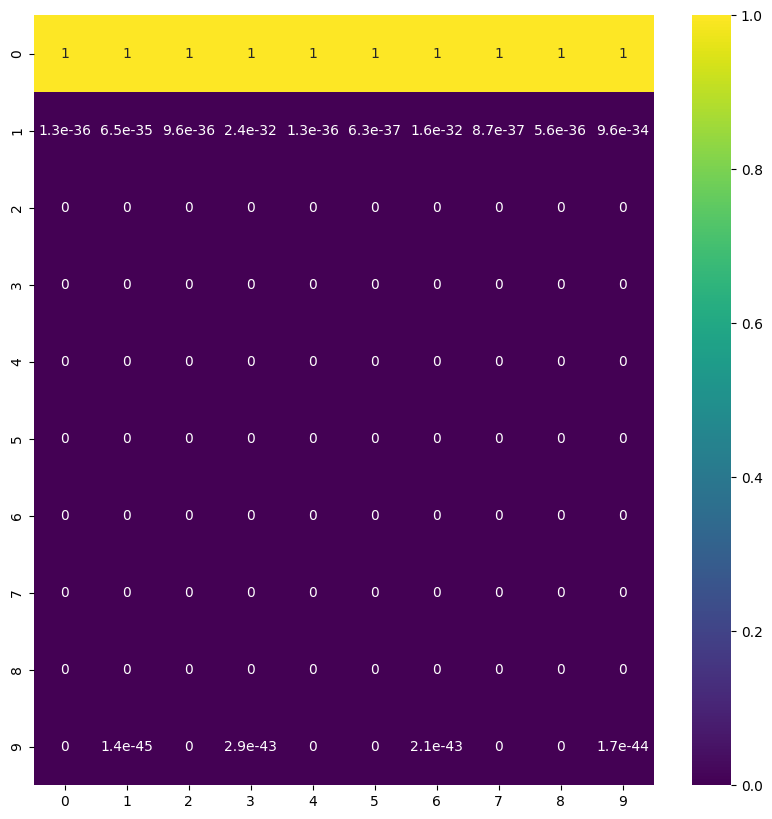

tensor([[245., 533., 394., 952., 248., 193., 927., 217., 355., 726.]],
       device='cuda:0') [2 6 5 9 3 0 8 1 4 7]
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])


In [139]:
getOutput(RawNumArrayDataset)

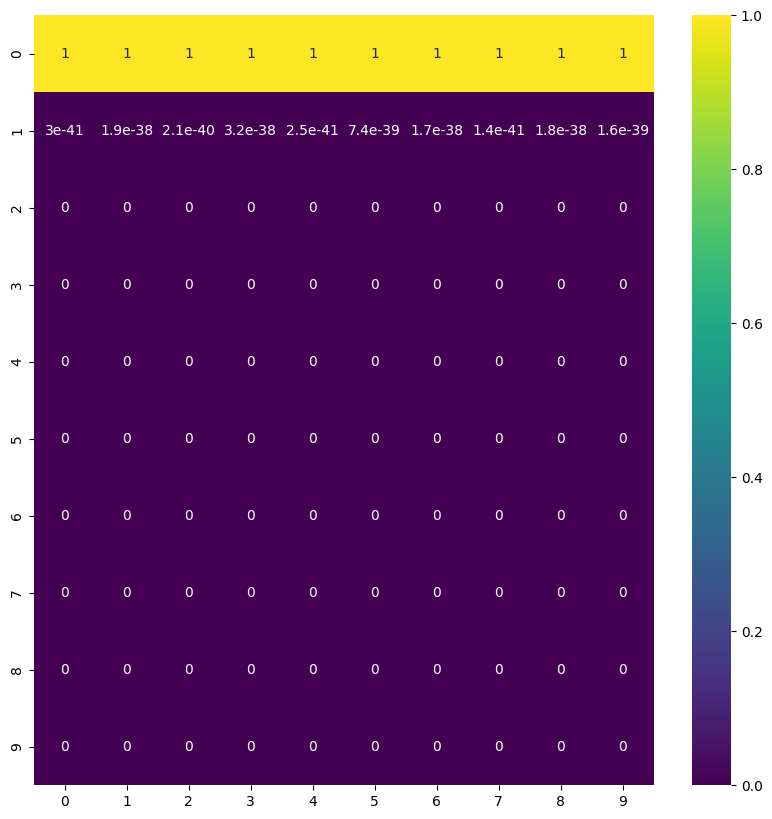

tensor([[0.0000, 0.9471, 0.5713, 1.0000, 0.3240, 0.8931, 0.9568, 0.0216, 0.9633,
         0.7732]], device='cuda:0') [0 6 3 9 2 5 7 1 8 4]
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])


In [140]:
getOutput(MaxminNumArrayDataset)

The original model depends on z-normalisation.

## Training on these datasets

In [141]:
def train(datasetClass,modelclass):

    (train_dataset, test_dataset, valid_dataset),(train_size, test_size, valid_size) = createDatasets(datasetClass,dataset,.1,.1)
    
    train_data = DataLoader(train_dataset,batch_size=64)
    valid_data = DataLoader(valid_dataset,batch_size=4096)
    test_data = DataLoader(test_dataset,batch_size=4096)
    max_epochs = 200
    learning_rate = 1e-3
    
    device = "cuda:0" if torch.cuda.is_available() else "cpu"
    #device = "cpu"
    model = modelclass(device)
    model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    
    opt = torch.optim.AdamW(model.parameters(),lr = learning_rate)
    
    model.train()
    accuracies = []
    losses = []
    for i in range(max_epochs):
        s = 0
        for (x,y) in train_data:
            x = x.to(device)
            y = y.to(device)
            pred = model(x)
            pred = pred.transpose(1,2)
            loss = loss_fn(pred,y)
            losses.append(loss.item())
            loss.backward()
            s+=loss.item()
            opt.step()
            opt.zero_grad()
        with torch.no_grad():
            total = 0
            for (x,y) in valid_data:
                x = x.to(device)
                y = y.to(device)
                pred = model(x)
                pred = torch.softmax(pred,dim=-1)
                pred = torch.argmax(pred,dim=-1)
                z = (y == pred).reshape(-1)
                #z = torch.where(z <= 0.5*4/33, 1,0)
                total += z.sum()
        accuracies.append((total/valid_size/10))
        if (i%10 == 0):
            print(accuracies[-1])
    
    model.eval()
    
    total = 0
    total2 = 0
    total3 = 0
    total4 = 0
    avg =0
    with torch.no_grad():
        for (x,y) in test_data:
            y = y.to(device)
            x = x.to(device)
            pred = model(x)
            pred = torch.softmax(pred,dim=-1)
            pred = torch.argmax(pred,dim=-1)
            z = (y == pred).reshape(-1)
            total+=z.sum()
            z = z.reshape(-1,10)
            total2 += torch.where(torch.sum(z,dim = -1) == 10, 1,0).sum()
            total3 += torch.where(abs(torch.sum(z,dim = -1)-10)<=1, 1,0).sum()
            total4 += torch.where(abs(torch.sum(z,dim = -1)-10)<=2, 1,0).sum()
            avg += abs(torch.sum(z,dim = -1)-10).sum()
    
    print("Test Accuracy (%):",total/test_size/10*100)
    print("Full sequence correct (%):",total2/test_size*100)
    print("Atmost 1 incorect sequence correct (%):",total3/test_size*100)
    print("Atmost 2 incorect sequence correct (%):",total4/test_size*100)
    print("Average no of rank predicted incorect in a sequence :",avg/test_size)
    return model

In [142]:
train(RawNumArrayDataset,EncoderOnlyTransformerPredictor2)

tensor(0.2328, device='cuda:0')
tensor(0.4955, device='cuda:0')
tensor(0.5016, device='cuda:0')
tensor(0.5039, device='cuda:0')
tensor(0.5066, device='cuda:0')
tensor(0.5080, device='cuda:0')
tensor(0.5069, device='cuda:0')
tensor(0.5074, device='cuda:0')
tensor(0.5055, device='cuda:0')
tensor(0.5039, device='cuda:0')
tensor(0.5020, device='cuda:0')
tensor(0.5038, device='cuda:0')
tensor(0.5070, device='cuda:0')
tensor(0.5046, device='cuda:0')
tensor(0.5023, device='cuda:0')
tensor(0.5047, device='cuda:0')
tensor(0.5036, device='cuda:0')
tensor(0.5059, device='cuda:0')
tensor(0.5059, device='cuda:0')
tensor(0.5034, device='cuda:0')
Test Accuracy (%): tensor(51.0700, device='cuda:0')
Full sequence correct (%): tensor(0.2000, device='cuda:0')
Atmost 1 incorect sequence correct (%): tensor(1.3000, device='cuda:0')
Atmost 2 incorect sequence correct (%): tensor(6.5000, device='cuda:0')
Average no of rank predicted incorect in a sequence : tensor(4.8930, device='cuda:0')


EncoderOnlyTransformerPredictor2(
  (att): MultiHeadAttention(
    (sf): Softmax(dim=-1)
  )
  (norm): AddAndNormalise()
  (r): ReLU()
)

In [100]:
train(MaxminNumArrayDataset,EncoderOnlyTransformerPredictor2)

tensor(0.5007, device='cuda:0')
tensor(0.6862, device='cuda:0')
tensor(0.7046, device='cuda:0')
tensor(0.7054, device='cuda:0')
tensor(0.7112, device='cuda:0')
tensor(0.7203, device='cuda:0')
tensor(0.7308, device='cuda:0')
tensor(0.7290, device='cuda:0')
tensor(0.7302, device='cuda:0')
tensor(0.7303, device='cuda:0')
tensor(0.7300, device='cuda:0')
tensor(0.7268, device='cuda:0')
tensor(0.7265, device='cuda:0')
tensor(0.7219, device='cuda:0')
tensor(0.6893, device='cuda:0')
tensor(0.7022, device='cuda:0')
tensor(0.7046, device='cuda:0')
tensor(0.7070, device='cuda:0')
tensor(0.7039, device='cuda:0')
tensor(0.7053, device='cuda:0')
Test Accuracy (%): tensor(71.0700, device='cuda:0')
Full sequence correct (%): tensor(3.1000, device='cuda:0')
Atmost 1 incorect sequence correct (%): tensor(14.3000, device='cuda:0')
Atmost 2 incorect sequence correct (%): tensor(38.2000, device='cuda:0')
Average no of rank predicted incorect in a sequence : tensor(2.8930, device='cuda:0')


In [99]:
train(ZScoreNumArrayDataset,EncoderOnlyTransformerPredictor2)

tensor(0.5493, device='cuda:0')
tensor(0.6274, device='cuda:0')
tensor(0.6767, device='cuda:0')
tensor(0.7148, device='cuda:0')
tensor(0.7480, device='cuda:0')
tensor(0.7528, device='cuda:0')
tensor(0.7591, device='cuda:0')
tensor(0.7622, device='cuda:0')
tensor(0.7664, device='cuda:0')
tensor(0.7685, device='cuda:0')
tensor(0.7702, device='cuda:0')
tensor(0.7680, device='cuda:0')
tensor(0.7721, device='cuda:0')
tensor(0.7722, device='cuda:0')
tensor(0.7774, device='cuda:0')
tensor(0.7782, device='cuda:0')
tensor(0.7806, device='cuda:0')
tensor(0.7815, device='cuda:0')
tensor(0.7839, device='cuda:0')
tensor(0.7838, device='cuda:0')
Test Accuracy (%): tensor(77.6300, device='cuda:0')
Full sequence correct (%): tensor(8.3000, device='cuda:0')
Atmost 1 incorect sequence correct (%): tensor(30.2000, device='cuda:0')
Atmost 2 incorect sequence correct (%): tensor(59.5000, device='cuda:0')
Average no of rank predicted incorect in a sequence : tensor(2.2370, device='cuda:0')


min max scaling and z-score are both give similar accuracy.

## Positional encoding Ablation

In [109]:
class EncoderOnlyTransformerPredictor3(torch.nn.Module):
    def __init__(self,device):
        super().__init__()
        self.device = device
        self.att = MultiHeadAttention(4,1,16,device)
        self.norm = AddAndNormalise()
        self.W_1 = nn.Parameter(torch.randn((4*16+1,64))/65**0.5)
        self.b_1 = nn.Parameter(torch.randn(64)*0.1)
        self.W_2 = nn.Parameter(torch.randn((64,10))/8)
        self.b_2 = nn.Parameter(torch.randn(10)*0.1)
        self.r = nn.ReLU()
        self.ff = lambda x : self.r(x@self.W_1+self.b_1)@self.W_2 + self.b_2

    def forward(self,x):
        x = x.reshape(-1,x.shape[1],1)
        x3 = self.att(x)
        x4 = self.norm(x,x3)
        
        x5 = self.ff(x4)
        return x5

    def position_embedded(self,x):
        x = x.reshape(-1,x.shape[1],1)
        P = torch.zeros_like(x)
        for i in range(x.shape[1]):
            P[:,i,0] = (1.5)**(-i)
            #P[:,i,0] = np.sin(i)
        return torch.concat([x,P], dim = -1)


In [144]:
model = train(ZScoreNumArrayDataset,EncoderOnlyTransformerPredictor3)

tensor(0.4208, device='cuda:0')
tensor(0.6025, device='cuda:0')
tensor(0.6164, device='cuda:0')
tensor(0.6350, device='cuda:0')
tensor(0.6389, device='cuda:0')
tensor(0.6410, device='cuda:0')
tensor(0.6448, device='cuda:0')
tensor(0.6491, device='cuda:0')
tensor(0.6520, device='cuda:0')
tensor(0.6563, device='cuda:0')
tensor(0.6577, device='cuda:0')
tensor(0.6594, device='cuda:0')
tensor(0.6607, device='cuda:0')
tensor(0.6623, device='cuda:0')
tensor(0.6639, device='cuda:0')
tensor(0.6649, device='cuda:0')
tensor(0.6629, device='cuda:0')
tensor(0.6650, device='cuda:0')
tensor(0.6651, device='cuda:0')
tensor(0.6642, device='cuda:0')
Test Accuracy (%): tensor(66.9000, device='cuda:0')
Full sequence correct (%): tensor(1.6000, device='cuda:0')
Atmost 1 incorect sequence correct (%): tensor(10.5000, device='cuda:0')
Atmost 2 incorect sequence correct (%): tensor(29.9000, device='cuda:0')
Average no of rank predicted incorect in a sequence : tensor(3.3100, device='cuda:0')


so the model does learn but not at a good scale.

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0')
tensor([[[2.3658e-04, 2.4400e-04, 4.2135e-02, 1.5988e-01, 1.3517e-01,
          1.6878e-01, 4.1483e-01, 7.8049e-02, 4.8910e-04, 1.8509e-04],
         [2.3658e-04, 2.4400e-04, 4.2135e-02, 1.5988e-01, 1.3517e-01,
          1.6878e-01, 4.1483e-01, 7.8049e-02, 4.8910e-04, 1.8509e-04],
         [2.3658e-04, 2.4400e-04, 4.2135e-02, 1.5988e-01, 1.3517e-01,
          1.6878e-01, 4.1483e-01, 7.8049e-02, 4.8910e-04, 1.8509e-04],
         [2.3658e-04, 2.4400e-04, 4.2135e-02, 1.5988e-01, 1.3517e-01,
          1.6878e-01, 4.1483e-01, 7.8049e-02, 4.8910e-04, 1.8509e-04],
         [2.3658e-04, 2.4400e-04, 4.2135e-02, 1.5988e-01, 1.3517e-01,
          1.6878e-01, 4.1483e-01, 7.8049e-02, 4.8910e-04, 1.8509e-04],
         [2.3658e-04, 2.4400e-04, 4.2135e-02, 1.5988e-01, 1.3517e-01,
          1.6878e-01, 4.1483e-01, 7.8049e-02, 4.8910e-04, 1.8509e-04],
         [2.3658e-04, 2.4400e-04, 4.2135e-02, 1.5988e-01, 1.3517e-01,
          1.6878e-

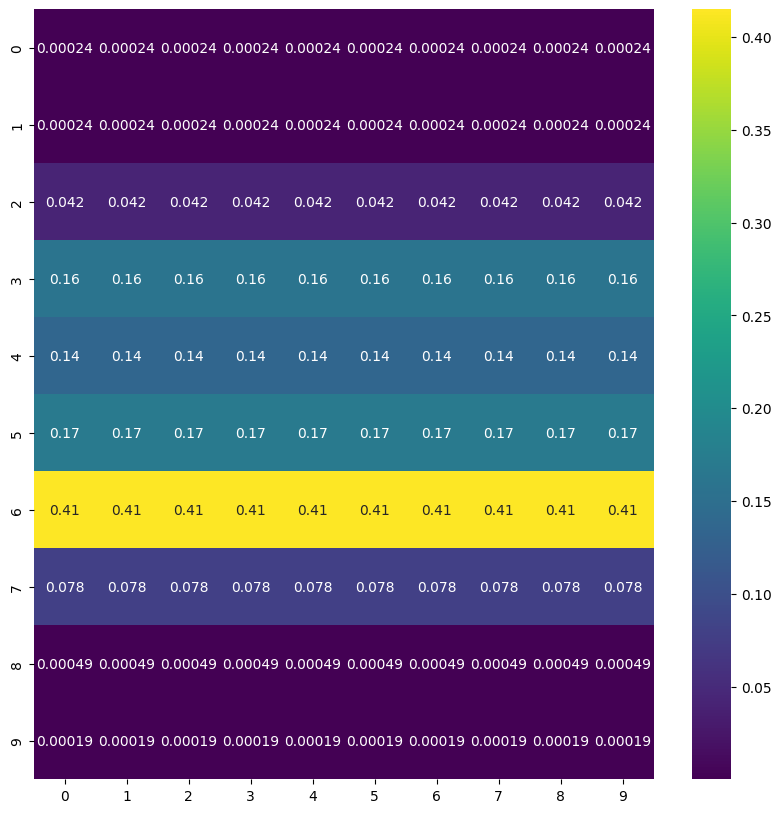

In [145]:
# Testing some examples

test = torch.Tensor([0,0,0,0,0,0,0,0,0,0]).to(device)
#test = (test - test.mean())/test.std()
x5 = model(test.reshape(1,10)).reshape(-1,10,10)
plt.figure(figsize=(10, 10))
print(test)
print(torch.softmax(x5,dim=-1).cpu())
sns.heatmap(torch.softmax(x5,dim=-1).mT.cpu().detach().numpy()[0],annot=True,cmap="viridis")
plt.show()

as we can see positional baises are removed.

## RNN/LSTM vs Transformer

We have seen both and transformer performs way better than other 2.

Self-attention is designed to understand global context and thus it helps the transformer too learn. Where even if we try to replicate it with rnn it doesn't perform well.

Moreover, it is obvious to see that multi headed attention helps to parrallism then rnn and lstm implementation.